# Fall & Call: Emergency Keyword Spotting (KWS) v2.0
This notebook trains a CNN model to recognize **"HELP"**, **"EMERGENCY"**, **"CANCEL"** and **"BACKGROUND NOISE"**.

It follows the standard TinyML workflow used in the gender classification project, ensuring compatibility with the Nano 33 BLE Sense audio capture.

### **Model Update**: This version uses `SeparableConv2D` for improved parameter efficiency on microcontrollers.

In [5]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D, Conv2D, Flatten
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import os
import shutil
import json

# Set MFCC parameters (Matching Lab 4 / Nano 33 BLE Sense specs)
N_MFCC = 13 
N_MELS = 26
SAMPLING_RATE = 16000 # 16 kHz
FRAME_SIZE = 512 # 32 ms
HOP_LENGTH = 256 # 16 ms
MIN_FREQ = 50
MAX_FREQ = SAMPLING_RATE / 2

# 1 second of audio at 16kHz = 16000 samples
# With center=False, n_frames = (16000 - 512) // 256 + 1 = 61
N_FRAMES = 61

# Precise length required for MFCC frames
TARGET_LENGTH = FRAME_SIZE + (N_FRAMES - 1) * HOP_LENGTH 
CLASSES = ['HELP', 'CANCEL', 'BACKGROUND']

print(f"Target Samples per Clip: {TARGET_LENGTH}")

Target Samples per Clip: 15872


**1. Load and preprocess the data**

In [6]:
def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    return audio / max_val if max_val > 0 else audio

def extract_mfcc(data):
    return librosa.feature.mfcc(
        y=data, sr=SAMPLING_RATE, n_mfcc=N_MFCC, n_mels=N_MELS,
        n_fft=FRAME_SIZE, hop_length=HOP_LENGTH, fmin=MIN_FREQ, fmax=MAX_FREQ,
        window='hann', center=False, dct_type=2, norm='ortho', power=2
    )

def process_csv_file(filename, label):
    print(f"Processing {filename}...")
    df = pd.read_csv(filename, header=None, on_bad_lines='skip')
    df = df.apply(pd.to_numeric, errors='coerce')
    raw_samples = df.dropna().values.flatten()
    
    mfccs, labels = [], []
    
    # Chunking with Padding (The Optimal Logic)
    num_full_snippets = len(raw_samples) // TARGET_LENGTH
    for i in range(num_full_snippets):
        snippet = raw_samples[i*TARGET_LENGTH : (i+1)*TARGET_LENGTH]
        mfcc = extract_mfcc(normalize_audio(snippet))
        mfccs.append(mfcc)
        labels.append(label)
        
    # Handle the remainder
    remainder = len(raw_samples) % TARGET_LENGTH
    if remainder > (TARGET_LENGTH // 2): # Only pad if remainder is significant
        snippet = raw_samples[-remainder:]
        pad_size = TARGET_LENGTH - remainder
        snippet = np.pad(snippet, (pad_size // 2, pad_size - (pad_size // 2)))
        mfcc = extract_mfcc(normalize_audio(snippet))
        mfccs.append(mfcc)
        labels.append(label)
        
    return np.array(mfccs), np.array(labels)

# --- Execution & Mel Filter Bank Export ---
all_x, all_y = [], []
for cls in CLASSES:
    x, y = process_csv_file(f"audio_{cls.lower()}.csv", cls)
    all_x.append(x)
    all_y.append(y)

X = np.vstack(all_x)
y = np.concatenate(all_y)

# Split Data
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = X[..., np.newaxis] # Add channel dimension (13, 61, 1)

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Final Class Mapping:", mapping)

x_train, x_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.4, stratify=y_encoded, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

Processing audio_help.csv...
Processing audio_cancel.csv...
Processing audio_background.csv...
Final Class Mapping: {np.str_('BACKGROUND'): np.int64(0), np.str_('CANCEL'): np.int64(1), np.str_('HELP'): np.int64(2)}


**3. Training the Model**

In [7]:
# -------------------------------
# 1. Reset model
# -------------------------------
tf.keras.backend.clear_session()

# -------------------------------
# 2. Reshape input for CNN
# -------------------------------
# In Audio: 
# Height = N_MFCC (Frequency bins)
# Width = N_FRAMES (Time steps)
train_mfccs_cnn = x_train.reshape(-1, N_MFCC, N_FRAMES, 1)
val_mfccs_cnn   = x_val.reshape(-1, N_MFCC, N_FRAMES, 1)
test_mfccs_cnn  = x_test.reshape(-1, N_MFCC, N_FRAMES, 1)

# -------------------------------
# 3. Build CNN model
# -------------------------------
model = tf.keras.models.Sequential([
    # Input shape: (13, 61, 1)
    tf.keras.layers.Input(shape=(N_MFCC, N_FRAMES, 1)),

    # Layer 1: Kernel (3, N_MFCC) 
    # Added padding='same' to prevent dimension collapse
    tf.keras.layers.SeparableConv2D(16, kernel_size=(3, N_MFCC), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)), # Standard 2x2 pool

    # Layer 2: Temporal filtering
    tf.keras.layers.SeparableConv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Layer 3: Temporal filtering
    tf.keras.layers.SeparableConv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(CLASSES), activation='softmax')
])

# -------------------------------
# 4. Compile
# -------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------------
# 5. Early stopping
# -------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# -------------------------------
# 6. Train
# -------------------------------
history = model.fit(
    train_mfccs_cnn, y_train,
    validation_data=(val_mfccs_cnn, y_val),
    epochs=200,
    batch_size=12,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# 7. Evaluate
# -------------------------------
actual_epochs = len(history.history['loss'])
print("Epochs actually run:", actual_epochs)
test_loss, test_acc = model.evaluate(test_mfccs_cnn, y_test)
print("\nTest Accuracy:", test_acc)


Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3260 - loss: 1.0988 - val_accuracy: 0.3443 - val_loss: 1.0617
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3370 - loss: 1.0645 - val_accuracy: 0.4262 - val_loss: 1.0421
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4309 - loss: 1.0307 - val_accuracy: 0.5410 - val_loss: 1.0110
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5525 - loss: 0.9774 - val_accuracy: 0.4918 - val_loss: 0.9802
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5414 - loss: 0.9307 - val_accuracy: 0.5082 - val_loss: 1.0209
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7127 - loss: 0.8554 - val_accuracy: 0.5738 - val_loss: 0.8900
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7182 - loss: 0.8017 - val_accuracy: 0.6230 - val_loss: 0.8728
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7348 - loss: 0.7362 - val_accuracy: 0.7213 -

**4. Evaluating the Model**

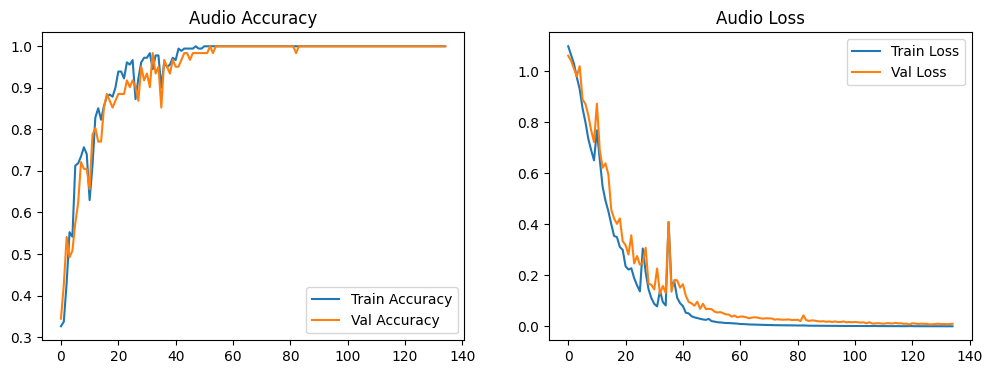

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy Plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Audio Accuracy')
ax[0].legend()

# Loss Plot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Audio Loss')
ax[1].legend()
plt.show()

**5. Confusion Matrix**

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


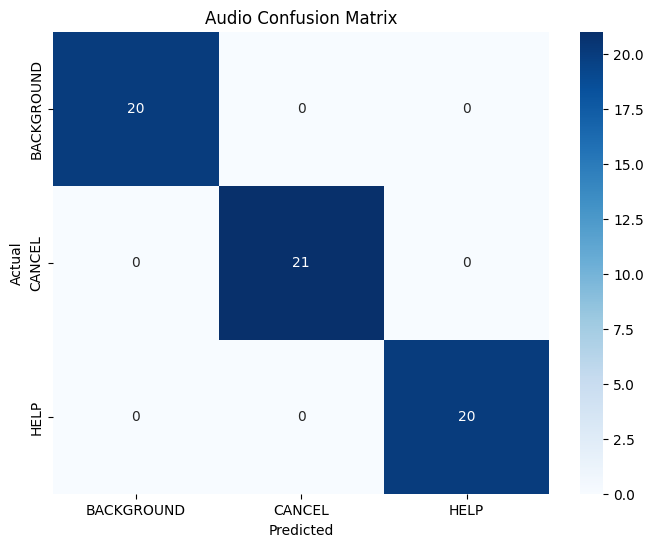

In [9]:
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Audio Confusion Matrix')
plt.show()

### Calculating Metrics

In [13]:
# Calculate Standard Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall    = recall_score(y_test, y_pred, average='macro')
f1        = f1_score(y_test, y_pred, average='macro')


# Print Results
print("--- Detailed Performance Metrics ---")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.4f}")

# Full Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

--- Detailed Performance Metrics ---
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

        HELP       1.00      1.00      1.00        20
      CANCEL       1.00      1.00      1.00        21
  BACKGROUND       1.00      1.00      1.00        20

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



**6. Export Model for Cloud Server**

In [12]:
model.save("emergency_model.h5")
print("Model saved as emergency_model.h5 for cloud server deployment.")

Model saved as emergency_model.h5 for cloud server deployment.
